# 📊 **Notebook : Visualisation des données d une eau potable**
## 🎯 **Objectifs :¶**
** Ce notebook permet à travers une exploration approfondie de la visualisation des données en utilisant Matplotlib, Seaborn et Plotly,**
** tout en appliquant des techniques avancées de storytelling**
**et suite a l entrainement d un modele de machine learning a determiner la potabilite d une eau.**

## 🛠 **Outils principaux :**
# 📦 `pandas`, `seaborn`, `matplotlib`, `plotly`, `sklearn`

In [1]:
!pip install xgboost

In [2]:
# 📦 Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.utils import resample

#from xgboost import XGBClassifier

import joblib

In [3]:
df = pd.read_csv("../data/water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
description = pd.read_csv("../data/water_quality_dataset_description.csv")
description

,Column,Unit,Description
0,ph,NaN,pH of water (0 to 14).
1,Hardness,mg/L,Capacity of water to precipitate soap.
2,Solids,ppm,Total dissolved solids.
3,Chloramines,ppm,Amount of Chloramines.
4,Sulfate,mg/L,Amount of Sulfates dissolved.
5,Conductivity,μS/cm,Electrical conductivity of water.
6,Organic_carbon,ppm,Amount of organic carbon.
7,Trihalomethanes,μg/L,Amount of Trihalomethanes.
8,Turbidity,NTU,Measure of light emitting property of water.
9,Potability,binary,Indicates if water is safe for human consumpti...


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

# 📌 **Analyse 1 : Do solids affect the potability of water?**

## 💡 **H₀ (Null hypothesise) :**  
**There is no significant influence on the potability of water due to solids.**  

## 💡 **H₁ (Alternative hypothesis) :**  
**There is significant influence on the potability of water due to solids.** 


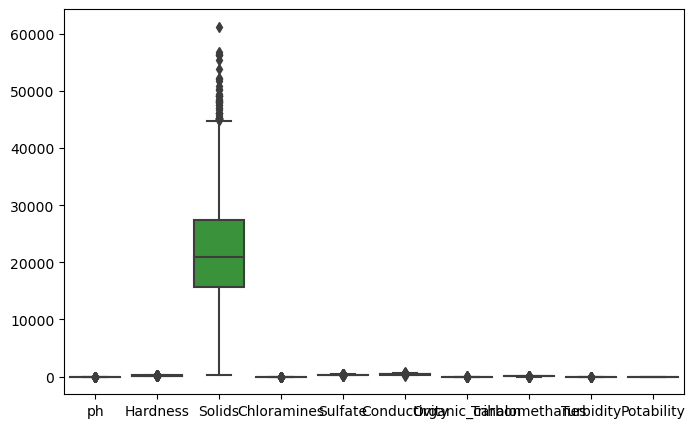

In [8]:
#potability water visualization by solids
plt.figure(figsize=(8, 5))
sns.boxplot(data=df)
plt.show()


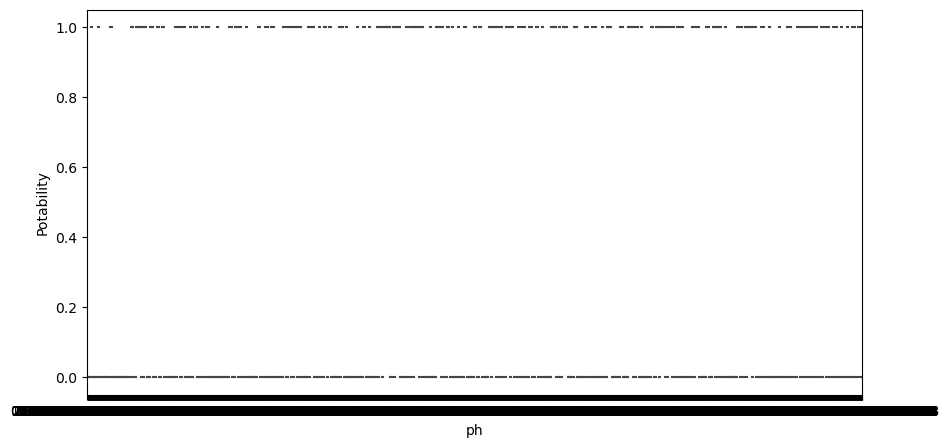

In [9]:
plt.figure(figsize=(10,5))
sns.violinplot(x="ph", y="Potability", data=df)
plt.show()

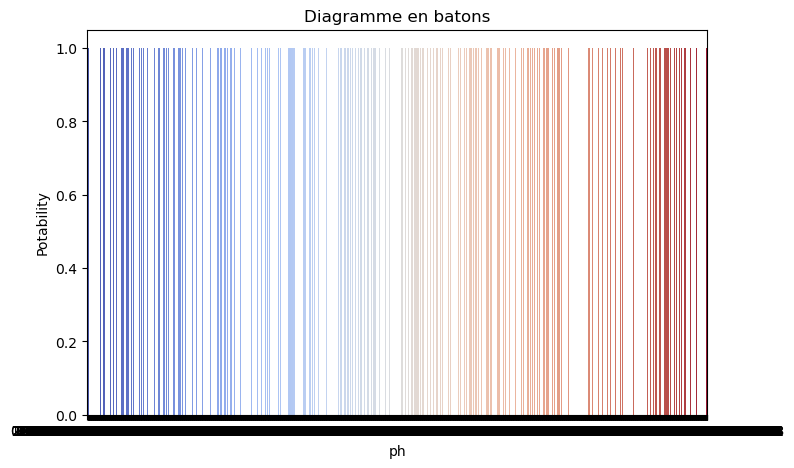

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x="ph", y="Potability", data=df, estimator=lambda x: x.mean(), errorbar = ('ci',95), palette="coolwarm")
plt.title("Diagramme en batons")
plt.xlabel("ph")
plt.ylabel("Potability")
plt.show()

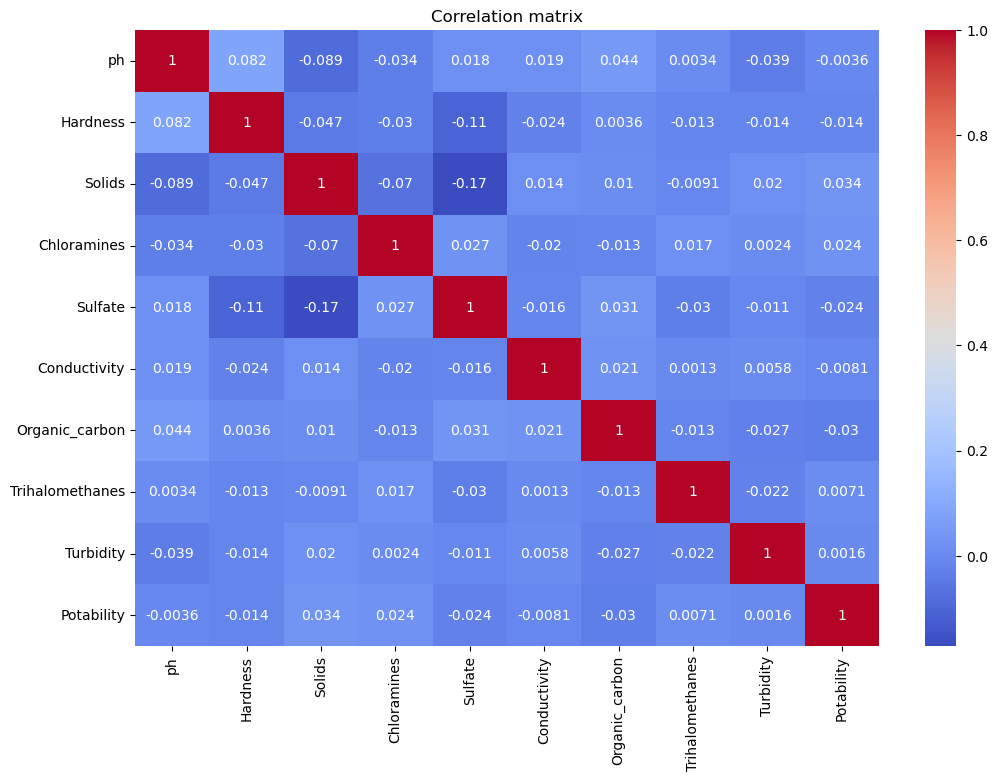

In [11]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("Correlation matrix")
plt.show()

In [12]:
'''
new_df = df
for col in [col for col in df.columns if col != 'Potability']:
    df2 = df
    df2[col] = df[col].mean()
    new_df = pd.concat([new_df,df2],axis=0)
df = new_df

df
'''

"\nnew_df = df\nfor col in [col for col in df.columns if col != 'Potability']:\n    df2 = df\n    df2[col] = df[col].mean()\n    new_df = pd.concat([new_df,df2],axis=0)\ndf = new_df\n\ndf\n"

In [13]:
#preprocessing outlierss
def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df


In [14]:
#traitement des outliers
df = treat_outliers_iqr(df, "Solids")

In [15]:
#remplacement des valeurs manquantes
df.fillna(df.median(numeric_only=True), inplace=True)

In [16]:
#reechantillonage
df_majority = df[df.Potability==0]
df_minority = df[df.Potability==1]

df_minority_upsampled = resample(df_minority, replace = True, n_samples = len(df_majority), random_state = 42)

df_upsampled = pd.concat([df_majority, df_minority_upsampled])
df = df_upsampled

In [17]:
#methode smote
X = df.drop("Potability", axis = 1)
y = df["Potability"]
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X, y)

In [18]:
#ajout de bruit suivant la normalisation gaussienne
def ajout_bruit(data, noise_level = 0.01):
    noise = np.random.normal(loc = 0, scale = noise_level*data.std(), size = data.shape)
    return data + noise


In [19]:
features = df.columns[-1]
df_noisy = df.copy()
df_noisy[features] = ajout_bruit(df[features])

In [20]:
#remplacement nan
num_feature = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
num_transform = Pipeline([
    ("impute", KNNImputer(n_neighbors = 5)),
    ("scaler", MinMaxScaler())
    
])

preprocesseur = ColumnTransformer([
    ("num", num_transform, num_feature), 
   
])
df_cleaned = preprocesseur.fit_transform(df)

In [21]:

df_clean = pd.DataFrame(df_cleaned, columns = num_feature)

In [22]:
df_clean.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.502625,0.571139,0.459896,0.537433,0.623236,0.669439,0.313402,0.699753,0.286091
1,0.265434,0.297400,0.411340,0.484644,0.504553,0.719411,0.497319,0.450999,0.576793
2,0.578509,0.641311,0.440085,0.694275,0.504553,0.414652,0.562017,0.532866,0.303637
3,0.594055,0.605536,0.487464,0.597697,0.584291,0.317880,0.622089,0.808065,0.601015
4,0.649445,0.484851,0.396713,0.477607,0.427743,0.379337,0.358555,0.253606,0.496327


In [23]:


df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df_clean, df["Potability"], test_size = 0.02, random_state = 42)

In [25]:
#fonction d'entrainement du modele
def train_model(model, xTrain, xTest, yTrain, yTest):
    print(model)
    model.fit(xTrain, yTrain)
    ypred = model.predict(xTest)
    report = classification_report(ypred, yTest)
    accuracy = accuracy_score(ypred, yTest)
    return ypred, accuracy

In [26]:
svm = SVC()
randomForest = RandomForestClassifier(n_estimators = 100, random_state = 42)
decisionTree = DecisionTreeClassifier(random_state=42)
logisticRegression = LogisticRegression()
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
models = [svm, randomForest, decisionTree, logisticRegression, gbc]

In [27]:
best_model = None
best_accuracy = 0
for model in models:
    ypred, accuracy = train_model(model, X_train, X_test, y_train, y_test)
    print("Accuracy:", accuracy)
    if best_accuracy < accuracy:
        best_accuracy = accuracy
        best_model = model

print("Le meilleur model est:", {best_model})
print("Avec un score de:", {best_accuracy})


SVC()
Accuracy: 0.6
RandomForestClassifier(random_state=42)
Accuracy: 0.8625
DecisionTreeClassifier(random_state=42)
Accuracy: 0.8125
LogisticRegression()
Accuracy: 0.4875
GradientBoostingClassifier(learning_rate=0.05, max_depth=4, random_state=42)
Accuracy: 0.7
Le meilleur model est: {RandomForestClassifier(random_state=42)}
Avec un score de: {0.8625}


In [28]:
joblib.dump(best_model, "best_model.joblib",compress=3)

['best_model.joblib']